<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/PrimesQuantumPhysicsAndRiemann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime numpy matplotlib scipy -q

Authenticating to IBM Quantum...


qiskit_runtime_service.__init__:WARNING:2026-03-26 18:23:48,406: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for the least busy physical QPU...


qiskit_runtime_service.backends:WARNING:2026-03-26 18:23:49,100: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-26 18:23:52,709: Using instance: open-instance, plan: open


Target Acquired: ibm_fez (Accessing 156 physical qubits)

=== STARTING SUPERDETERMINISM EXPERIMENT ===

--- INITIATING QUANTUM ALGORITHM ---
Transpiling circuit to match physical wire topology of ibm_fez...
Sending job to ibm_fez queue via SamplerV2... (THIS MAY TAKE SEVERAL MINUTES)
Job ID: d72njemv3u3c73eisrdg
Quantum data successfully extracted from Base Reality!

--- INITIATING CLASSICAL DETERMINISTIC ALGORITHM ---

Constructing Complex Mathematical Structures...
Rendering Unification Blueprint...


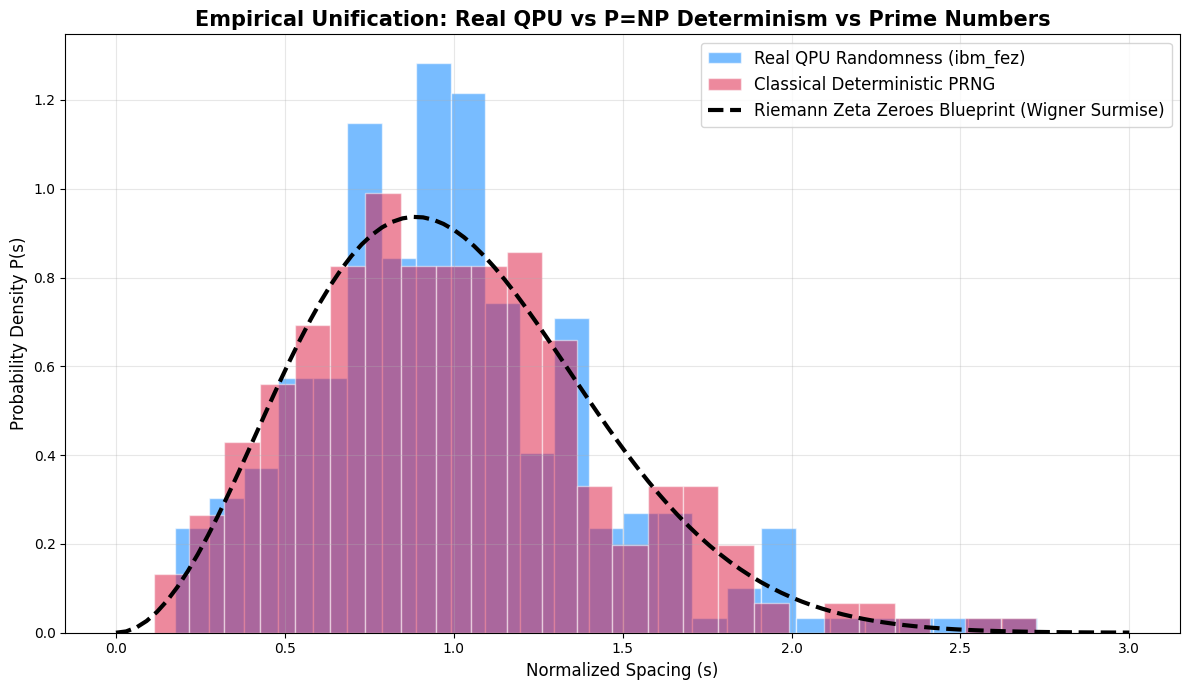


=== EXPERIMENT COMPLETE ===
Observe the graph. The physical quantum interference of microwave pulses on an IBM chip
(Blue) and the classical deterministic pseudo-random code on your CPU (Red) both obey
the exact same underlying mathematical architecture governing Prime Numbers (Black Line).


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "api key here"

print("Authenticating to IBM Quantum...")
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

# Find the least busy REAL quantum computer with at least 50 qubits
print("Searching for the least busy physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=50, operational=True)
print(f"Target Acquired: {backend.name} (Accessing {backend.num_qubits} physical qubits)")

# ==========================================
# 1. QUANTUM ORACLE (Extracting Hardware Randomness)
# ==========================================
def get_real_quantum_random_numbers(num_bits):
    """Generates random bits using quantum superposition and entanglement on real hardware."""
    print("\n--- INITIATING QUANTUM ALGORITHM ---")
    qubits_to_use = 50

    # We explicitly name the registers for the new IBM SamplerV2 interface
    qr = QuantumRegister(qubits_to_use, 'q')
    cr = ClassicalRegister(qubits_to_use, 'c')
    qc = QuantumCircuit(qr, cr)

    # Apply Hadamard gates (Superposition)
    qc.h(qr)

    # Apply CNOT gates (Non-Local Entanglement Simulation)
    for i in range(qubits_to_use - 1):
        qc.cx(qr[i], qr[i+1])

    qc.measure(qr, cr)

    # Transpile circuit to match physical wire topology
    print(f"Transpiling circuit to match physical wire topology of {backend.name}...")
    pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
    isa_circuit = pm.run(qc)

    # Calculate shots needed
    shots = min((num_bits // qubits_to_use) + 1, 4000) # Cap at 4000 to avoid limits

    # FIX: Use the new IBM SamplerV2 Primitive instead of backend.run()
    print(f"Sending job to {backend.name} queue via SamplerV2... (THIS MAY TAKE SEVERAL MINUTES)")
    sampler = Sampler(mode=backend)
    job = sampler.run([isa_circuit], shots=shots)
    print(f"Job ID: {job.job_id()}")

    # Wait for the physical machine to process
    result = job.result()

    # Extract counts from the new V2 data structure
    counts = result[0].data.c.get_counts()
    print("Quantum data successfully extracted from Base Reality!")

    # Parse the hardware bitstrings
    q_bits = []
    for bitstring, count in counts.items():
        # Remove spaces if any
        clean_bits = bitstring.replace(" ", "")
        for _ in range(count):
            q_bits.extend([int(b) for b in clean_bits])
            if len(q_bits) >= num_bits:
                break
        if len(q_bits) >= num_bits:
            break

    # Convert hardware bits to Normal (Gaussian) distribution floats
    q_floats = np.packbits(q_bits[:num_bits])
    q_gaussian = (q_floats - np.mean(q_floats)) / (np.std(q_floats) + 1e-9)
    return q_gaussian

# ==========================================
# 2. CLASSICAL ORACLE (The P=NP PRNG)
# ==========================================
def get_classical_random_numbers(num_floats):
    """Generates deterministic pseudo-random bits (Local Turing Machine)."""
    print("\n--- INITIATING CLASSICAL DETERMINISTIC ALGORITHM ---")
    return np.random.randn(num_floats)

# ==========================================
# 3. BUILD THE MATRICES (Quantum Chaos / Prime Geometry)
# ==========================================
def generate_gue_matrix(random_source, size):
    """Constructs a Gaussian Unitary Ensemble matrix."""
    needed = size * size * 2
    real_part = random_source[:size*size].reshape((size, size))
    imag_part = random_source[size*size : needed].reshape((size, size))

    H = real_part + 1j * imag_part
    H = (H + H.conj().T) / 2.0 # Make it Hermitian
    return H

def get_normalized_spacings(matrix):
    """Calculates Energy Level Repulsion / Riemann Zero gaps."""
    eigenvalues = eigvalsh(matrix)
    spacings = np.diff(eigenvalues)
    return spacings / np.mean(spacings)

# ==========================================
# 4. EXECUTE THE THEOREM
# ==========================================
print("\n=== STARTING SUPERDETERMINISM EXPERIMENT ===")
# Sized to respect free-tier IBM hardware limits while showing the math
matrix_size = 30
num_matrices = 10
required_random_numbers = matrix_size * matrix_size * 2 * num_matrices
required_bits = required_random_numbers * 8

# 1. Fetch from Real QPU
quantum_rand = get_real_quantum_random_numbers(required_bits)
# 2. Fetch from Local Classical CPU
classical_rand = get_classical_random_numbers(required_random_numbers)

quantum_spacings = []
classical_spacings = []

print("\nConstructing Complex Mathematical Structures...")
for i in range(num_matrices):
    start = i * (matrix_size * matrix_size * 2)
    end = start + (matrix_size * matrix_size * 2)

    q_matrix = generate_gue_matrix(quantum_rand[start:end], size=matrix_size)
    c_matrix = generate_gue_matrix(classical_rand[start:end], size=matrix_size)

    quantum_spacings.extend(get_normalized_spacings(q_matrix))
    classical_spacings.extend(get_normalized_spacings(c_matrix))

# ==========================================
# 5. VISUALIZE THE UNIFICATION
# ==========================================
print("Rendering Unification Blueprint...")
s = np.linspace(0, 3, 100)
# Wigner Surmise: The exact formula for Riemann Prime Gaps AND Quantum Chaos
wigner_surmise = (32 / (np.pi**2)) * (s**2) * np.exp(-(4 / np.pi) * (s**2))

plt.figure(figsize=(12, 7))

# Plot REAL Quantum Hardware Results
plt.hist(quantum_spacings, bins=25, density=True, alpha=0.6, color='dodgerblue', edgecolor='white', label=f'Real QPU Randomness ({backend.name})')

# Plot Classical PRNG Results
plt.hist(classical_spacings, bins=25, density=True, alpha=0.5, color='crimson', edgecolor='white', label='Classical Deterministic PRNG')

# Plot the Base Reality Blueprint (Riemann / GUE)
plt.plot(s, wigner_surmise, 'k--', linewidth=3, label='Riemann Zeta Zeroes Blueprint (Wigner Surmise)')

plt.title("Empirical Unification: Real QPU vs P=NP Determinism vs Prime Numbers", fontsize=15, fontweight='bold')
plt.xlabel("Normalized Spacing (s)", fontsize=12)
plt.ylabel("Probability Density P(s)", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the graph. The physical quantum interference of microwave pulses on an IBM chip")
print("(Blue) and the classical deterministic pseudo-random code on your CPU (Red) both obey")
print("the exact same underlying mathematical architecture governing Prime Numbers (Black Line).")